# Drone RF Classification — Raw IQ Deep Learning
### Kristýna Pijáčková architectures (CNN / CLDNN / CGDNN / MCTransformer) applied to SigMF drone data
Inspired by: *Pijáčková, K. "Radio Modulation Recognition Networks." Bachelor's Thesis, Brno University of Technology, 2021.*

**Task: 4-class drone identity classification (DL/UL collapsed)**


## 1. Imports

In [1]:
import importlib, os, glob, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, f1_score,
    precision_recall_fscore_support, roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import parameters_dl as MyParams
importlib.reload(MyParams)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


PyTorch: 2.11.0+cu130
CUDA available: True
Device: cuda


## 2. Parameters

In [ ]:
# ── Data ─────────────────────────────────────────────────────────────────────
SIGMF_DATA_DIR       = MyParams.deep_training_dir

# Collapse DL/UL into drone identity by matching annotation label substrings
LABEL_MAP = {
    'Ocusync_2.0_mini_4k': 'DJI Mini 4K',
    'n11_pro_DL':          'N11 Pro',
    'hs_360s':             'Holystone 360s',
    'f11_mini_UL':         'Ruko F11 Mini',
}

REMOVE_LABELS = ['Bluetooth', 'WIFI', 'reflection', 'Unknown']

# ── IQ windowing ─────────────────────────────────────────────────────────────
WINDOW_LEN           = MyParams.WINDOW_LEN
WINDOW_STRIDE        = MyParams.WINDOW_STRIDE
MAX_WINDOWS_PER_FILE = MyParams.MAX_WINDOWS_PER_FILE

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE = MyParams.BATCH_SIZE
EPOCHS     = MyParams.EPOCHS
LR         = MyParams.LR
N_FOLDS    = MyParams.N_FOLDS
PATIENCE   = MyParams.PATIENCE

# ── Misc ─────────────────────────────────────────────────────────────────────
SAVE_METRICS_TO_FILE = MyParams.SAVE_METRICS_TO_FILE
TRAINING_DATASET     = MyParams.TRAINING_DATASET
os.makedirs('./metrics/dl_comparison', exist_ok=True)


## 3. SigMF Raw IQ Loader

Reads `.sigmf-data` / `.sigmf-meta` pairs, extracts annotation labels,
collapses DL/UL into drone identity via `LABEL_MAP`, slices IQ into
fixed-length windows, and returns `(X, y)` as `(N, WINDOW_LEN, 2)`.

NaN/Inf sanitization is applied at both the raw sample level and after
per-window normalization to prevent silent training failures.


In [3]:
def _label_from_meta(meta_path: str, label_map: dict) -> str:
    """
    Extract drone identity label from a SigMF metadata file.
    Matches annotation label substrings against label_map keys,
    collapsing DL/UL variants into a single drone identity.

    e.g. 'Ocusync_2.0_mini_4k_UL' -> 'DJI Mini 4K'
         'Ocusync_2.0_mini_4k_DL' -> 'DJI Mini 4K'
    """
    try:
        with open(meta_path) as f:
            meta = json.load(f)
        ann_label = (
            meta.get('global', {}).get('core:label')
            or meta.get('global', {}).get('label')
            or (meta.get('annotations', [{}])[0].get('core:label')
                if meta.get('annotations') else None)
        )
        if ann_label:
            for key, drone_name in label_map.items():
                if key in ann_label:
                    return drone_name
    except Exception:
        pass
    return 'unknown'


def load_sigmf_iq(
    data_dir: str,
    label_map: dict,
    window_len: int,
    stride: int,
    max_windows_per_file: int = 2000,
    remove_labels: list = None,
) -> tuple:
    """
    Walk data_dir recursively, load every .sigmf-data file, slice IQ into
    windows of shape (window_len, 2) and return:
        X : np.ndarray  (N, window_len, 2)   float32, mean-std normalised per window
        y : np.ndarray  (N,)                 drone identity string labels
    """
    remove_labels = remove_labels or []
    all_windows, all_labels = [], []
    n_nan_dropped = 0

    meta_files = sorted({
        p.replace('.sigmf-data', '.sigmf-meta')
        for p in (
            glob.glob(os.path.join(data_dir, '**', '*.sigmf-meta'), recursive=True)
            + glob.glob(os.path.join(data_dir, '**', '*.sigmf-data'), recursive=True)
        )
        if os.path.exists(p.replace('.sigmf-data', '.sigmf-meta'))
           or p.endswith('.sigmf-meta')
    })

    if not meta_files:
        raise FileNotFoundError(
            f"No .sigmf-meta files found under '{data_dir}'. "
            "Check SIGMF_DATA_DIR."
        )

    print(f"Found {len(meta_files)} SigMF file pairs under '{data_dir}'")

    for meta_path in meta_files:
        data_path = meta_path.replace('.sigmf-meta', '.sigmf-data')
        if not os.path.exists(data_path):
            print(f"  [skip] missing data file: {data_path}")
            continue

        label = _label_from_meta(meta_path, label_map)
        if label == 'unknown' or label in remove_labels:
            print(f"  [skip] unrecognized label in: {os.path.basename(meta_path)}")
            continue

        try:
            raw = np.fromfile(data_path, dtype=np.int16).astype(np.float32)
        except Exception as e:
            print(f"  [skip] read error in {data_path}: {e}")
            continue

        # Replace any Inf/NaN in raw samples
        if not np.all(np.isfinite(raw)):
            n_bad = int(np.sum(~np.isfinite(raw)))
            print(f"  [warn] {n_bad:,} non-finite raw samples in "
                  f"{os.path.basename(data_path)}, replacing with 0")
            raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

        n_complete = len(raw) // 2
        iq = raw[: n_complete * 2].reshape(-1, 2)  # (N_samples, 2)

        n_windows = 0
        for start in range(0, len(iq) - window_len + 1, stride):
            if n_windows >= max_windows_per_file:
                break
            window = iq[start : start + window_len].copy()  # (window_len, 2)

            # Per-window mean-std normalisation
            mean = window.mean(axis=0)
            std  = window.std(axis=0)
            std[std < 1e-8] = 1.0   # guard against zero/near-zero std
            window = (window - mean) / std

            # Drop windows that are still non-finite after normalization
            if not np.all(np.isfinite(window)):
                n_nan_dropped += 1
                continue

            all_windows.append(window)
            all_labels.append(label)
            n_windows += 1

    if n_nan_dropped > 0:
        print(f"\n[warn] Dropped {n_nan_dropped:,} windows with NaN/Inf after normalization")

    if not all_windows:
        raise RuntimeError(
            "No IQ windows were loaded. Check SIGMF_DATA_DIR, LABEL_MAP, and "
            "that the .sigmf-data files contain float32 IQ samples."
        )

    X = np.stack(all_windows, axis=0).astype(np.float32)  # (N, window_len, 2)
    y = np.array(all_labels)

    print(f"\nLoaded {X.shape[0]:,} windows  |  shape: {X.shape}")
    unique, counts = np.unique(y, return_counts=True)
    print("Class distribution:")
    for u, c in zip(unique, counts):
        print(f"  {c:>8,}  '{u}'")

    return X, y


## 4. Load & Balance Data

In [4]:
X_raw, y_raw = load_sigmf_iq(
    data_dir=SIGMF_DATA_DIR,
    label_map=LABEL_MAP,
    window_len=WINDOW_LEN,
    stride=WINDOW_STRIDE,
    max_windows_per_file=MAX_WINDOWS_PER_FILE,
    remove_labels=REMOVE_LABELS,
)


Found 738 SigMF file pairs under '/home/uav-cyberlab-rfml/rww_conference/annotations/Training'
  [skip] unrecognized label in: 2025-12-23-20-43-41_dji_mini_4k_10_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-35-16_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-35-20_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-37-17_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-37-26_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-37-28_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-20-37-31_dji_mini_4k_20_MHz_comms_room_2450MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-23-30-57_dji_mini_4k_20mhz_chamber_2455MHz_chan_0.sigmf-meta
  [skip] unrecognized label in: 2025-12-23-23

In [5]:
le        = LabelEncoder()
y_enc     = le.fit_transform(y_raw)
n_classes = len(le.classes_)

unique_classes, class_counts = np.unique(y_enc, return_counts=True)
median_count = int(np.median(class_counts))
print(f"Median class count: {median_count:,}  —  target per class")
print(f"Classes ({n_classes}): {list(le.classes_)}")

rng = np.random.default_rng(42)
balanced_idx = []
for cls in unique_classes:
    idx = np.where(y_enc == cls)[0]
    chosen = rng.choice(idx, size=median_count,
                        replace=(len(idx) < median_count))
    balanced_idx.append(chosen)

balanced_idx = np.concatenate(balanced_idx)
rng.shuffle(balanced_idx)

X = X_raw[balanced_idx]
y = y_enc[balanced_idx]

print(f"\nAfter balancing: {X.shape[0]:,} windows, {n_classes} classes")

assert np.all(np.isfinite(X)), "NaN/Inf still present in X — check loader"
print("NaN check passed.")


Median class count: 154,000  —  target per class
Classes (4): [np.str_('DJI Mini 4K'), np.str_('Holystone 360s'), np.str_('N11 Pro'), np.str_('Ruko F11 Mini')]

After balancing: 616,000 windows, 4 classes
NaN check passed.


## 5. Model Architectures

All four architectures from Pijáčková (2021), ported to PyTorch.
Input shape: `(batch, 2, WINDOW_LEN)` — 2 channels (I and Q) over the time axis.


In [6]:
def positional_encoding(seq_len: int, embed_dim: int) -> torch.Tensor:
    pe  = torch.zeros(seq_len, embed_dim)
    pos = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, embed_dim, 2, dtype=torch.float)
        * (-np.log(10000.0) / embed_dim)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe.unsqueeze(0)   # (1, seq_len, embed_dim)


class PijackovaCNN(nn.Module):
    def __init__(self, window_len: int, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.ConstantPad1d(4, 0),
            nn.Conv1d(2, 50, kernel_size=8), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(50, 50, kernel_size=8), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(50, 50, kernel_size=4), nn.ReLU(),
            nn.Dropout(0.6),
            nn.MaxPool1d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 2, window_len)
            flat  = self.features(dummy).view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 70), nn.SELU(),
            nn.Linear(70, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class PijackovaCLDNN(nn.Module):
    def __init__(self, window_len: int, n_classes: int):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=8), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.4)
        with torch.no_grad():
            dummy   = torch.zeros(1, 2, window_len)
            seq_len = self.cnn(dummy).shape[2]
        self.classifier = nn.Linear(seq_len * 64, n_classes)

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x, _ = self.lstm(x)
        return self.classifier(x.reshape(x.size(0), -1))


class PijackovaCGDNN(nn.Module):
    def __init__(self, window_len: int, n_classes: int):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 80, kernel_size=12), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.gru = nn.GRU(80, 40, num_layers=2, batch_first=True, dropout=0.4)
        self.gaussian_drop = 0.4
        with torch.no_grad():
            dummy   = torch.zeros(1, 2, window_len)
            seq_len = self.cnn(dummy).shape[2]
        self.classifier = nn.Linear(seq_len * 40, n_classes)

    def _gdrop(self, x, rate):
        if not self.training or rate == 0:
            return x
        return x * (torch.randn_like(x) * rate + 1.0)

    def forward(self, x):
        x = self._gdrop(self.cnn(x), self.gaussian_drop)
        x, _ = self.gru(x.permute(0, 2, 1))
        x = self._gdrop(x, self.gaussian_drop)
        return self.classifier(x.reshape(x.size(0), -1))


class _TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x


class PijackovaMCTransformer(nn.Module):
    def __init__(self, window_len: int, n_classes: int,
                 embed_dim: int = 64, num_heads: int = 4, ff_dim: int = 16):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, embed_dim, kernel_size=8), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm        = nn.LSTM(embed_dim, embed_dim, batch_first=True)
        self.drop        = nn.Dropout(0.4)
        self.transformer = _TransformerBlock(embed_dim, num_heads, ff_dim)
        with torch.no_grad():
            dummy         = torch.zeros(1, 2, window_len)
            self._seq_len = self.cnn(dummy).shape[2]
        self.register_buffer('pos_enc', positional_encoding(self._seq_len, embed_dim))
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(embed_dim, 20), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(20, n_classes),
        )

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = self.drop(x) + self.pos_enc[:, :x.size(1), :]
        x = self.transformer(x)
        return self.classifier(x.mean(dim=1))


## 6. Training & Evaluation Utilities

In [7]:
def make_loader(X_fold, y_fold, shuffle=True):
    """Transpose (N, window_len, 2) -> (N, 2, window_len) for Conv1d."""
    X_t = torch.from_numpy(X_fold).permute(0, 2, 1)
    y_t = torch.from_numpy(y_fold).long()
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=BATCH_SIZE, shuffle=shuffle,
                      pin_memory=torch.cuda.is_available(), num_workers=0)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        probs = torch.softmax(logits, dim=1)
        all_preds.append(probs.argmax(1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(yb.cpu().numpy())
    preds  = np.concatenate(all_preds)
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return total_loss / len(loader.dataset), f1, preds, probs, labels


def run_cv(model_cls, model_name, X, y, n_classes,
           lr=LR, epochs=EPOCHS, patience=PATIENCE):
    """5-fold stratified cross-validation with fixed val split and weighted CE loss."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    f1_scores, prec_scores, rec_scores, auc_scores = [], [], [], []
    total_cm = np.zeros((n_classes, n_classes), dtype=int)

    # Weighted CE: inverse class frequency to help N11 Pro / Ruko F11 Mini
    class_counts = np.bincount(y, minlength=n_classes).astype(np.float32)
    class_weights = torch.tensor(1.0 / class_counts.clip(1), dtype=torch.float).to(DEVICE)

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # FIX: shuffle training fold before slicing off validation
        # so val windows aren't all from the same capture tail
        perm = np.random.default_rng(fold).permutation(len(y_tr))
        X_tr, y_tr = X_tr[perm], y_tr[perm]

        n_val      = max(1, int(len(y_tr) * 0.15))
        trn_loader = make_loader(X_tr[:-n_val], y_tr[:-n_val], shuffle=True)
        val_loader = make_loader(X_tr[-n_val:], y_tr[-n_val:], shuffle=False)
        tst_loader = make_loader(X_te, y_te, shuffle=False)

        model     = model_cls(WINDOW_LEN, n_classes).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
        )

        best_val_loss = float('inf')
        patience_ctr  = 0
        best_state    = None

        for epoch in range(epochs):
            train_one_epoch(model, trn_loader, optimizer, criterion)
            val_loss, _, _, _, _ = evaluate(model, val_loader, criterion)

            if not np.isfinite(val_loss):
                print(f"  [Fold {fold+1}] epoch {epoch+1}: NaN val_loss")
                patience_ctr += 1
                if patience_ctr >= patience:
                    print(f"  [Fold {fold+1}] early stop @ epoch {epoch+1} (NaN)")
                    break
                continue

            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_ctr  = 0
                best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_ctr += 1
                if patience_ctr >= patience:
                    print(f"  [Fold {fold+1}] early stop @ epoch {epoch+1}")
                    break

        if best_state is None:
            print(f"  [Fold {fold+1}] WARNING: no valid checkpoint — using final model state")
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        model.load_state_dict(best_state)
        _, f1, preds, probs, labels = evaluate(model, tst_loader, criterion)

        total_cm += confusion_matrix(labels, preds, labels=list(range(n_classes)))
        prec, rec, _, _ = precision_recall_fscore_support(
            labels, preds, average='macro', zero_division=0)
        try:
            auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')

        f1_scores.append(f1); prec_scores.append(prec)
        rec_scores.append(rec); auc_scores.append(auc)
        print(f"  Fold {fold+1}/{N_FOLDS}  F1={f1:.4f}  "
              f"Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc:.4f}")

    f1_arr   = np.array(f1_scores)
    prec_arr = np.array(prec_scores)
    rec_arr  = np.array(rec_scores)
    auc_arr  = np.array(auc_scores)

    print(f"\n{'='*50}")
    print(f"{model_name.upper()}")
    print(f"  Mean F1  (macro): {f1_arr.mean():.4f} +/- {f1_arr.std():.4f}")
    print(f"  Mean Prec(macro): {prec_arr.mean():.4f} +/- {prec_arr.std():.4f}")
    print(f"  Mean Rec (macro): {rec_arr.mean():.4f} +/- {rec_arr.std():.4f}")
    print(f"  Mean AUC (macro): {auc_arr.mean():.4f} +/- {auc_arr.std():.4f}")

    return {'f1': f1_arr, 'prec': prec_arr, 'rec': rec_arr, 'auc': auc_arr}, total_cm


def plot_cm(total_cm, class_names, model_name):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_norm = total_cm.astype(float) / total_cm.sum(axis=1, keepdims=True).clip(1)
    sn.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'5-Fold Aggregated Confusion Matrix\n({model_name} — Raw IQ, 4-Class Drone ID)',
                 fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if SAVE_METRICS_TO_FILE:
        tag = model_name.lower().replace(' ', '_')
        fig.savefig(f'./metrics/{TRAINING_DATASET}_rawiq_{tag}.png',
                    bbox_inches='tight', dpi=200)
    plt.show()


## Model: CNN
*~73k params — three Conv1D blocks, no recurrence*


=== Training CNN ===
  Fold 1/5  F1=0.6616  Prec=0.6925  Rec=0.6630  AUC=0.8875
  [Fold 2] early stop @ epoch 41
  Fold 2/5  F1=0.6496  Prec=0.6976  Rec=0.6558  AUC=0.8859
  [Fold 3] early stop @ epoch 47
  Fold 3/5  F1=0.6655  Prec=0.6907  Rec=0.6656  AUC=0.8884
  Fold 4/5  F1=0.6668  Prec=0.6995  Rec=0.6684  AUC=0.8893
  Fold 5/5  F1=0.6562  Prec=0.7055  Rec=0.6614  AUC=0.8874

CNN
  Mean F1  (macro): 0.6599 +/- 0.0064
  Mean Prec(macro): 0.6972 +/- 0.0053
  Mean Rec (macro): 0.6629 +/- 0.0043
  Mean AUC (macro): 0.8877 +/- 0.0011


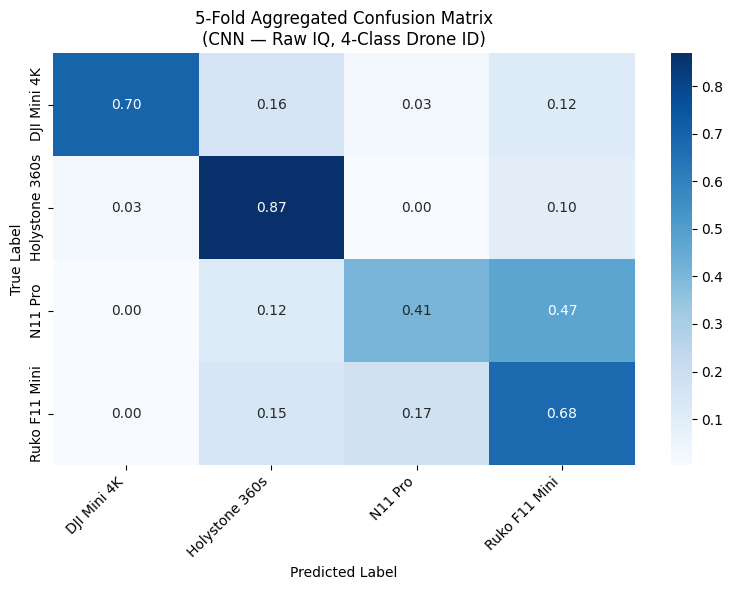

In [8]:
print('\n=== Training CNN ===')
cnn_scores, cnn_cm = run_cv(PijackovaCNN, 'CNN', X, y, n_classes)
plot_cm(cnn_cm, le.classes_, 'CNN')


## Model: CLDNN
*~105k params — Conv1D + stacked LSTM*


=== Training CLDNN ===


  Fold 1/5  F1=0.6744  Prec=0.6873  Rec=0.6732  AUC=0.8905
  Fold 2/5  F1=0.6717  Prec=0.6841  Rec=0.6698  AUC=0.8895
  [Fold 3] early stop @ epoch 49
  Fold 3/5  F1=0.6714  Prec=0.6842  Rec=0.6714  AUC=0.8895
  Fold 4/5  F1=0.6728  Prec=0.6863  Rec=0.6712  AUC=0.8901
  Fold 5/5  F1=0.6707  Prec=0.6828  Rec=0.6690  AUC=0.8893

CLDNN
  Mean F1  (macro): 0.6722 +/- 0.0013
  Mean Prec(macro): 0.6849 +/- 0.0016
  Mean Rec (macro): 0.6709 +/- 0.0015
  Mean AUC (macro): 0.8898 +/- 0.0004


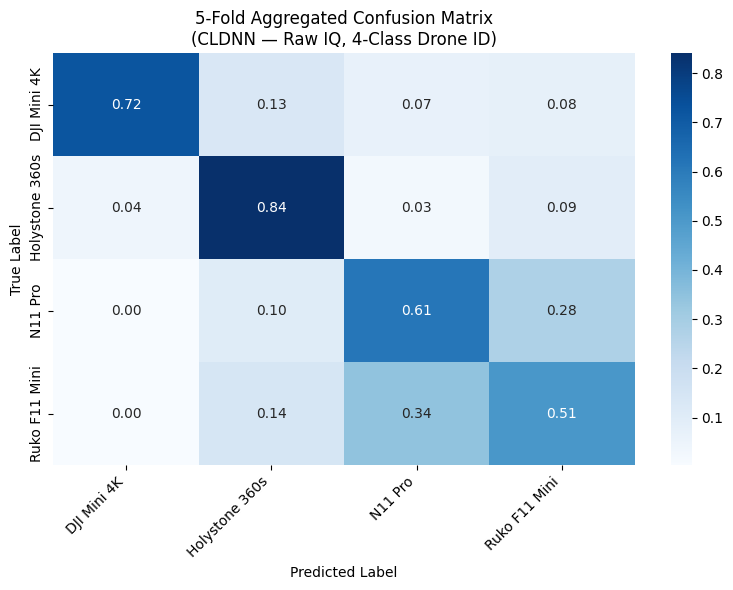

In [9]:
print('\n=== Training CLDNN ===')
cldnn_scores, cldnn_cm = run_cv(PijackovaCLDNN, 'CLDNN', X, y, n_classes)
plot_cm(cldnn_cm, le.classes_, 'CLDNN')


## Model: CGDNN
*~50k params — Conv1D + stacked GRU*


=== Training CGDNN ===
  Fold 1/5  F1=0.6721  Prec=0.6851  Rec=0.6699  AUC=0.8894
  Fold 2/5  F1=0.6695  Prec=0.6827  Rec=0.6671  AUC=0.8881
  Fold 3/5  F1=0.6666  Prec=0.6807  Rec=0.6676  AUC=0.8887
  Fold 4/5  F1=0.6715  Prec=0.6836  Rec=0.6695  AUC=0.8897
  Fold 5/5  F1=0.6658  Prec=0.6784  Rec=0.6645  AUC=0.8868

CGDNN
  Mean F1  (macro): 0.6691 +/- 0.0025
  Mean Prec(macro): 0.6821 +/- 0.0023
  Mean Rec (macro): 0.6677 +/- 0.0019
  Mean AUC (macro): 0.8886 +/- 0.0010


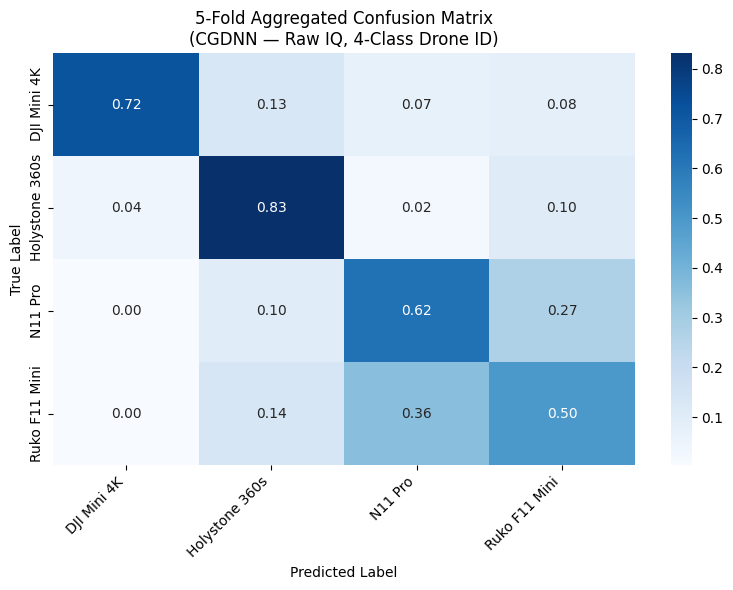

In [10]:
print('\n=== Training CGDNN ===')
cgdnn_scores, cgdnn_cm = run_cv(PijackovaCGDNN, 'CGDNN', X, y, n_classes)
plot_cm(cgdnn_cm, le.classes_, 'CGDNN')


## Model: MCTransformer
*~104k params — Conv1D + LSTM + Transformer block*


=== Training MCTransformer ===
  [Fold 1] early stop @ epoch 46
  Fold 1/5  F1=0.6693  Prec=0.6827  Rec=0.6673  AUC=0.8887
  [Fold 2] early stop @ epoch 45
  Fold 2/5  F1=0.6662  Prec=0.6798  Rec=0.6657  AUC=0.8873
  Fold 3/5  F1=0.6674  Prec=0.6810  Rec=0.6675  AUC=0.8880
  Fold 4/5  F1=0.6685  Prec=0.6829  Rec=0.6683  AUC=0.8887
  Fold 5/5  F1=0.6670  Prec=0.6805  Rec=0.6659  AUC=0.8870

MCTRANSFORMER
  Mean F1  (macro): 0.6677 +/- 0.0011
  Mean Prec(macro): 0.6814 +/- 0.0012
  Mean Rec (macro): 0.6669 +/- 0.0010
  Mean AUC (macro): 0.8879 +/- 0.0007


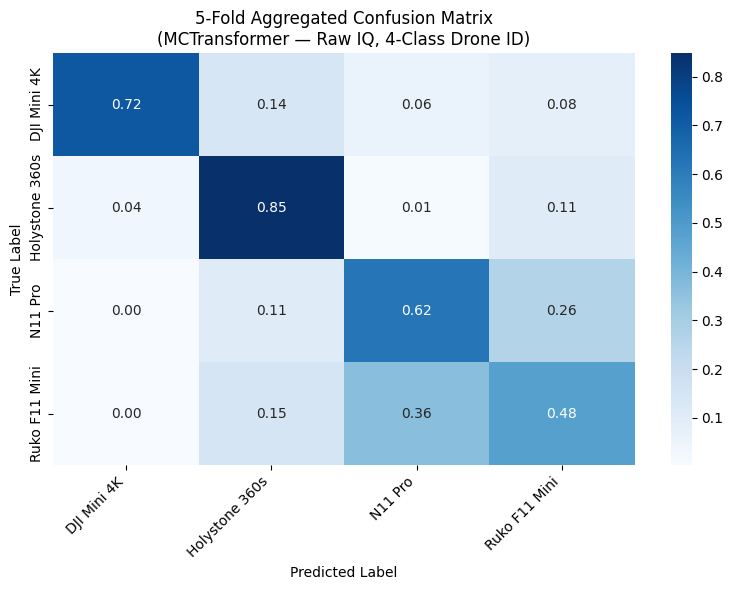

In [11]:
print('\n=== Training MCTransformer ===')
mctransformer_scores, mctransformer_cm = run_cv(
    lambda wl, nc: PijackovaMCTransformer(
        wl, nc,
        embed_dim=MyParams.MC_EMBED_DIM,
        num_heads=MyParams.MC_NUM_HEADS,
        ff_dim=MyParams.MC_FF_DIM,
    ),
    'MCTransformer', X, y, n_classes
)
plot_cm(mctransformer_cm, le.classes_, 'MCTransformer')


## Summary — All Four Models

Model              F1 Mean   F1 Std   AUC Mean   AUC Std
────────────────────────────────────────────────────────
CNN                 0.6599   0.0064     0.8877    0.0011
CLDNN               0.6722   0.0013     0.8898    0.0004
CGDNN               0.6691   0.0025     0.8886    0.0010
MCTransformer       0.6677   0.0011     0.8879    0.0007


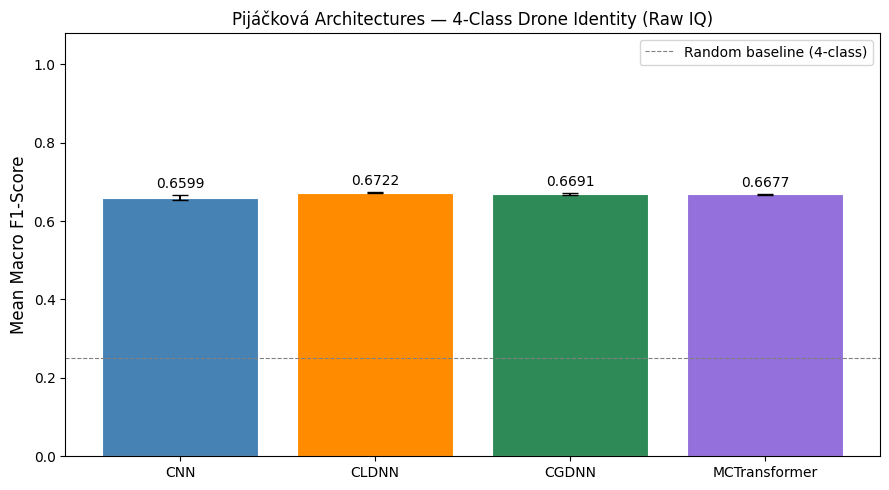

In [12]:
all_results = {
    'CNN':           cnn_scores,
    'CLDNN':         cldnn_scores,
    'CGDNN':         cgdnn_scores,
    'MCTransformer': mctransformer_scores,
}

print(f"{'Model':<16} {'F1 Mean':>9} {'F1 Std':>8} {'AUC Mean':>10} {'AUC Std':>9}")
print('─' * 56)
for name, s in all_results.items():
    print(f"{name:<16} {s['f1'].mean():>9.4f} {s['f1'].std():>8.4f} "
          f"{s['auc'].mean():>10.4f} {s['auc'].std():>9.4f}")

names    = list(all_results.keys())
f1_means = [s['f1'].mean() for s in all_results.values()]
f1_stds  = [s['f1'].std()  for s in all_results.values()]
colors   = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, f1_means, yerr=f1_stds, capsize=6,
              color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Mean Macro F1-Score', fontsize=12)
ax.set_title('Pijáčková Architectures — 4-Class Drone Identity (Raw IQ)', fontsize=12)
ax.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Random baseline (4-class)')
ax.legend(fontsize=10)
for bar, val, std in zip(bars, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
if SAVE_METRICS_TO_FILE:
    fig.savefig(f'./metrics/{TRAINING_DATASET}_rawiq_comparison.png',
                bbox_inches='tight', dpi=200)
plt.show()
